# GenkiClean Vending Analytics | Sales Distribution, Location & Performance Analysis

# 1. Contexto del negocio

GenkiClean opera un modelo de distribución automatizado a través de máquinas vending, que funcionan como puntos de venta 24/7 para productos de limpieza.

Este modelo permite:

- ampliar la disponibilidad del producto
- reducir dependencia de canales tradicionales
- capturar ventas directas al consumidor
- generar datos operativos en tiempo real

El canal vending se convierte así en una fuente estratégica tanto de ingresos como de información para la toma de decisiones.

## Objetivo del análisis

El objetivo de este proyecto es analizar el comportamiento de ventas del canal vending para entender:

- cómo se distribuyen las ventas diarias
- qué tan variable es el desempeño
- qué factores influyen en el rendimiento (ubicación, ciudad, tipo de cliente)

# 2. Problema de negocio

Aunque el canal vending genera ventas de forma constante, no existe una visibilidad clara sobre:

- la distribución real de ingresos
- la variabilidad entre máquinas
- el impacto de la ubicación en el desempeño
- qué factores explican el éxito o bajo rendimiento de ciertas máquinas

Esto limita la capacidad de tomar decisiones estratégicas como:

- dónde instalar nuevas máquinas
- cómo optimizar pricing y portafolio
- cómo mejorar el desempeño de máquinas existentes

## Enfoque del análisis

Para abordar este problema, se desarrolló un análisis en tres niveles:

1. Análisis global del sistema (distribución de ventas)
2. Análisis por segmentos (ciudad y tipo de ubicación)
3. Identificación de patrones y oportunidades de optimización

El objetivo es transformar datos operativos en insights accionables para el crecimiento del negocio.

## 2.1 Definición del indicador principal

Dado que el dataset no contiene identificadores de transacciones individuales, se define el ticket como:

Venta diaria por máquina.

Este indicador permite analizar:

- comportamiento de consumo
- estabilidad operativa
- desempeño relativo entre máquinas

In [8]:
import pandas as pd

In [9]:
url = "https://docs.google.com/spreadsheets/d/1A-K_PXVYFBF82epSx7ou3d68SE2Dd-lpQfOwLtkvalE/export?format=csv&gid=317475660"

In [10]:
df = pd.read_csv(url)

## 3. Exploración inicial del dataset

En esta etapa reviso la estructura del dataset para entender qué información contiene, qué columnas están disponibles y si los tipos de datos son adecuados para el análisis.

El objetivo es identificar las variables necesarias para calcular el ticket por compra, especialmente:

- Identificador de venta
- Fecha de venta
- Producto
- Cantidad vendida
- Ingreso total
- Canal de venta

In [11]:
df.head()

,date,year_month,machine_id,city,region,location_type,client_account,product_id,product_name,product_category,...,discount_pct,gross_sales_mxn,discount_mxn,net_sales_mxn,cogs_mxn,gross_margin_mxn,gross_margin_pct,avg_selling_price_per_liter_mxn,uptime_factor,incident_count
0,2025-01-01,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,86.05,0.0,86.05,46.10,39.95,0.4643,35.41,1.0,0
1,2025-01-02,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,121.81,0.0,121.81,65.26,56.55,0.4642,35.41,1.0,0
2,2025-01-03,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,117.92,0.0,117.92,63.17,54.75,0.4643,35.41,1.0,0
3,2025-01-04,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,110.48,0.0,110.48,59.19,51.29,0.4642,35.41,1.0,0
4,2025-01-05,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,101.27,0.0,101.27,54.25,47.02,0.4643,35.41,1.0,0


### 3.1 Columnas disponibles

Primero reviso los nombres de las columnas para identificar qué variables puedo usar en el análisis.
### 3.2 Tipos de datos

Después reviso los tipos de datos. Esto es importante porque las fechas deben estar en formato de fecha y los montos deben estar en formato numérico para poder analizarlos correctamente.

In [12]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183960 entries, 0 to 183959
Data columns (total 27 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   date                             183960 non-null  object 
 1   year_month                       183960 non-null  object 
 2   machine_id                       183960 non-null  object 
 3   city                             183960 non-null  object 
 4   region                           183960 non-null  object 
 5   location_type                    183960 non-null  object 
 6   client_account                   183960 non-null  object 
 7   product_id                       183960 non-null  object 
 8   product_name                     183960 non-null  object 
 9   product_category                 183960 non-null  object 
 10  transactions                     183960 non-null  int64  
 11  liters_sold_l                    183960 non-null  float64
 12  fo

### 3.3 Resumen estadístico

Reviso un resumen estadístico de las variables numéricas para detectar valores mínimos, máximos, promedios y posibles inconsistencias.

In [13]:
df.describe()

,transactions,liters_sold_l,forecast_liters_l,stockout_liters_l,stockout_flag,stockout_minutes,promotion_flag,discount_pct,gross_sales_mxn,discount_mxn,net_sales_mxn,cogs_mxn,gross_margin_mxn,gross_margin_pct,avg_selling_price_per_liter_mxn,uptime_factor,incident_count
count,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000,183960.000000
mean,6.033023,4.203494,3.906104,0.003842,0.001093,0.418721,0.088666,0.542031,174.812968,0.726836,174.086132,83.791138,90.294994,0.518938,43.675998,0.992033,0.043721
std,3.127483,2.191218,1.250657,0.149962,0.033037,15.979556,0.284262,2.424423,88.346426,3.750769,87.879769,42.898109,46.136139,0.040907,13.290058,0.043896,0.208712
min,0.000000,0.000000,0.830000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.461400,0.000000
25%,4.000000,2.860000,2.990000,0.000000,0.000000,0.000000,0.000000,0.000000,121.310000,0.000000,120.860000,57.620000,62.290000,0.491300,36.170000,1.000000,0.000000
50%,5.000000,3.750000,3.730000,0.000000,0.000000,0.000000,0.000000,0.000000,157.720000,0.000000,157.070000,75.840000,81.220000,0.517900,41.220000,1.000000,0.000000
75%,7.000000,4.950000,4.640000,0.000000,0.000000,0.000000,0.000000,0.000000,204.700000,0.000000,203.760000,98.720000,105.710000,0.545900,53.270000,1.000000,0.000000
max,65.000000,46.000000,10.380000,18.570000,1.000000,842.000000,1.000000,15.000000,1854.420000,129.890000,1854.420000,832.260000,1022.160000,0.623100,72.570000,1.000000,2.000000


### 3.4 Valores nulos

Identifico si existen datos faltantes que puedan afectar el análisis de tickets o ingresos.

In [14]:
df.isnull().sum()

date                               0
year_month                         0
machine_id                         0
city                               0
region                             0
location_type                      0
client_account                     0
product_id                         0
product_name                       0
product_category                   0
transactions                       0
liters_sold_l                      0
forecast_liters_l                  0
stockout_liters_l                  0
stockout_flag                      0
stockout_minutes                   0
promotion_flag                     0
discount_pct                       0
gross_sales_mxn                    0
discount_mxn                       0
net_sales_mxn                      0
cogs_mxn                           0
gross_margin_mxn                   0
gross_margin_pct                   0
avg_selling_price_per_liter_mxn    0
uptime_factor                      0
incident_count                     0
d

### 3.5 Identificación de variables clave

Para calcular la distribución del ticket de compra, necesito identificar:

- La columna que representa cada venta o transacción.
- La columna que representa el ingreso total de cada línea de venta.

Si el dataset está a nivel producto, será necesario agrupar por venta para obtener el ticket total.

In [15]:
df.head(10)

,date,year_month,machine_id,city,region,location_type,client_account,product_id,product_name,product_category,...,discount_pct,gross_sales_mxn,discount_mxn,net_sales_mxn,cogs_mxn,gross_margin_mxn,gross_margin_pct,avg_selling_price_per_liter_mxn,uptime_factor,incident_count
0,2025-01-01,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,86.05,0.0,86.05,46.10,39.95,0.4643,35.41,1.0,0
1,2025-01-02,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,121.81,0.0,121.81,65.26,56.55,0.4642,35.41,1.0,0
2,2025-01-03,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,117.92,0.0,117.92,63.17,54.75,0.4643,35.41,1.0,0
3,2025-01-04,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,110.48,0.0,110.48,59.19,51.29,0.4642,35.41,1.0,0
4,2025-01-05,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,101.27,0.0,101.27,54.25,47.02,0.4643,35.41,1.0,0
5,2025-01-06,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,126.77,0.0,126.77,67.91,58.86,0.4643,35.41,1.0,0
6,2025-01-07,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,140.58,0.0,140.58,75.31,65.27,0.4643,35.41,1.0,0
7,2025-01-08,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,106.58,0.0,106.58,57.10,49.48,0.4643,35.41,1.0,0
8,2025-01-09,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,101.27,0.0,101.27,54.25,47.02,0.4643,35.41,1.0,0
9,2025-01-10,2025-01,VM-001,Monterrey,Norte,Hotel,Grupo Horizonte,P01,Detergente multiusos,Limpieza general,...,0,116.85,0.0,116.85,62.60,54.25,0.4643,35.41,1.0,0


## 4. Construcción del ticket de análisis

El dataset no contiene identificador de venta individual, por lo que se define el ticket como:

Venta diaria por máquina.

Esto permite analizar cómo se distribuyen los ingresos en el canal vending a lo largo del tiempo y entender el comportamiento de consumo.

In [16]:
tickets = (
    df.groupby(["date", "machine_id"])["net_sales_mxn"]
    .sum()
    .reset_index()
)

tickets.head()

,date,machine_id,net_sales_mxn
0,2025-01-01,VM-001,573.05
1,2025-01-01,VM-002,724.63
2,2025-01-01,VM-003,837.63
3,2025-01-01,VM-004,691.61
4,2025-01-01,VM-005,945.11


## 5. Distribución de ventas diarias

Se analiza la distribución de ingresos diarios por máquina para entender:

- concentración de ventas
- variabilidad del desempeño
- presencia de días de alto o bajo ingreso

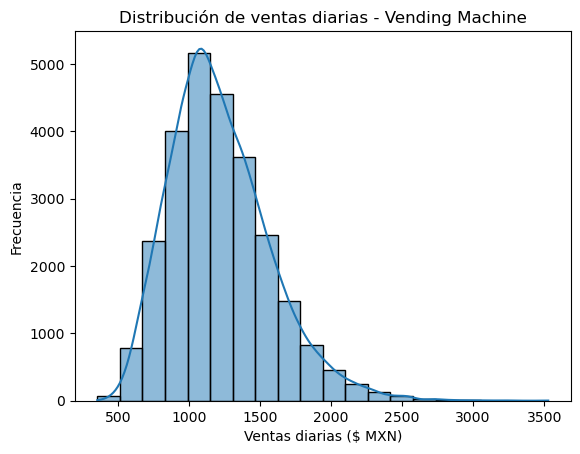

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=tickets, x="net_sales_mxn", bins=20, kde=True)

plt.title("Distribución de ventas diarias - Vending Machine")
plt.xlabel("Ventas diarias ($ MXN)")
plt.ylabel("Frecuencia")
plt.show()

## 6. Métricas clave

Se calculan métricas para entender el comportamiento general del canal vending.

In [18]:
tickets["net_sales_mxn"].describe()

count    26280.000000
mean      1218.602925
std        354.061953
min        355.280000
25%        968.292500
50%       1172.835000
75%       1425.360000
max       3528.350000
Name: net_sales_mxn, dtype: float64

## 7. Insights

La distribución de ventas diarias muestra el comportamiento del canal vending en términos de generación de ingresos.

La mayoría de los días se concentra en un rango medio de ventas, lo que sugiere un patrón relativamente estable en la operación.

La presencia de valores más altos indica que existen días con mayor demanda, posiblemente asociados a factores como ubicación, tráfico o comportamiento del cliente.

## Implicaciones

- El modelo presenta estabilidad operativa, pero con variabilidad relevante en el desempeño diario
- Existe oportunidad de incrementar ventas en días promedio mediante promociones o ajustes de pricing
- Identificar patrones en días de alto desempeño puede permitir replicar condiciones de éxito

## 8. Ajuste de visualización

El dataset contiene 72 máquinas vending. Al intentar visualizar la distribución de ventas usando una categoría por cada máquina, la gráfica se vuelve difícil de interpretar debido al exceso de colores y elementos en la leyenda.

Por esta razón, se ajusta el enfoque visual para obtener insights más claros mediante tres niveles de análisis:

1. Distribución general del sistema.
2. Comparación por grupos de máquinas.
3. Análisis de las máquinas con mayor desempeño.

### 8.1 Distribución general de ventas diarias

Primero se analiza la distribución general de ventas diarias por máquina, sin segmentar por cada vending machine. Esto permite entender el comportamiento global del canal.

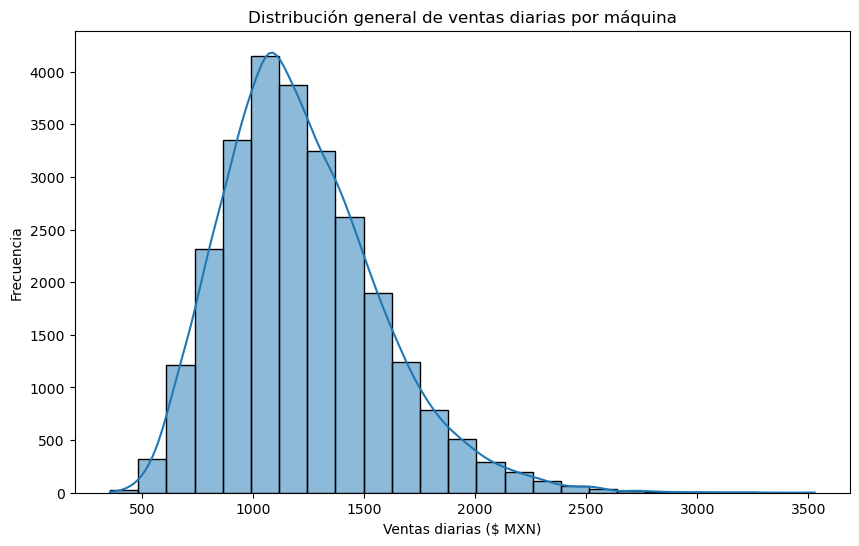

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=tickets,
    x="net_sales_mxn",
    bins=25,
    kde=True
)

plt.title("Distribución general de ventas diarias por máquina")
plt.xlabel("Ventas diarias ($ MXN)")
plt.ylabel("Frecuencia")
plt.show()

### 8.2 Agrupación de máquinas

Para evitar una visualización saturada, se agrupan las máquinas en rangos. Esto permite comparar bloques de máquinas sin perder claridad visual.

In [20]:
tickets["machine_number"] = tickets["machine_id"].str.replace("VM-", "").astype(int)

tickets["machine_group"] = pd.cut(
    tickets["machine_number"],
    bins=[0, 18, 36, 54, 72],
    labels=["VM 001-018", "VM 019-036", "VM 037-054", "VM 055-072"]
)

tickets.head()

,date,machine_id,net_sales_mxn,machine_number,machine_group
0,2025-01-01,VM-001,573.05,1,VM 001-018
1,2025-01-01,VM-002,724.63,2,VM 001-018
2,2025-01-01,VM-003,837.63,3,VM 001-018
3,2025-01-01,VM-004,691.61,4,VM 001-018
4,2025-01-01,VM-005,945.11,5,VM 001-018


### 8.3 Distribución de ventas por grupo de máquinas

Se visualizan las ventas diarias agrupadas por rangos de máquinas. Esto permite identificar si ciertos grupos presentan comportamientos de venta diferentes.

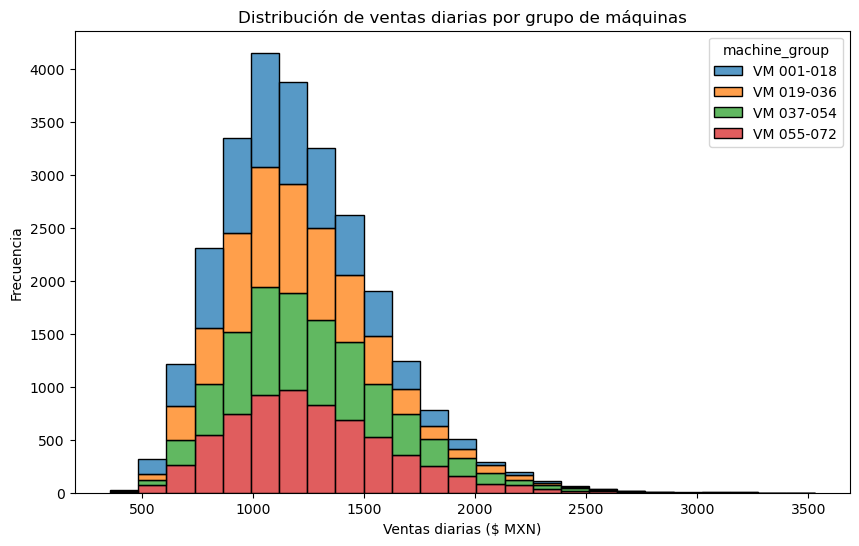

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=tickets,
    x="net_sales_mxn",
    hue="machine_group",
    bins=25,
    kde=False,
    multiple="stack"
)

plt.title("Distribución de ventas diarias por grupo de máquinas")
plt.xlabel("Ventas diarias ($ MXN)")
plt.ylabel("Frecuencia")
plt.show()

### 8.4 Máquinas con mayor venta promedio

Después se identifican las cinco máquinas con mayor venta diaria promedio para analizar si su distribución es distinta al comportamiento general.

In [22]:
top_machines = (
    tickets.groupby("machine_id")["net_sales_mxn"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_machines

Index(['VM-061', 'VM-042', 'VM-072', 'VM-021', 'VM-016'], dtype='object', name='machine_id')

### 8.5 Distribución de ventas en las Top 5 máquinas

Se filtran las máquinas con mejor desempeño para comparar su comportamiento de ventas de forma más clara.

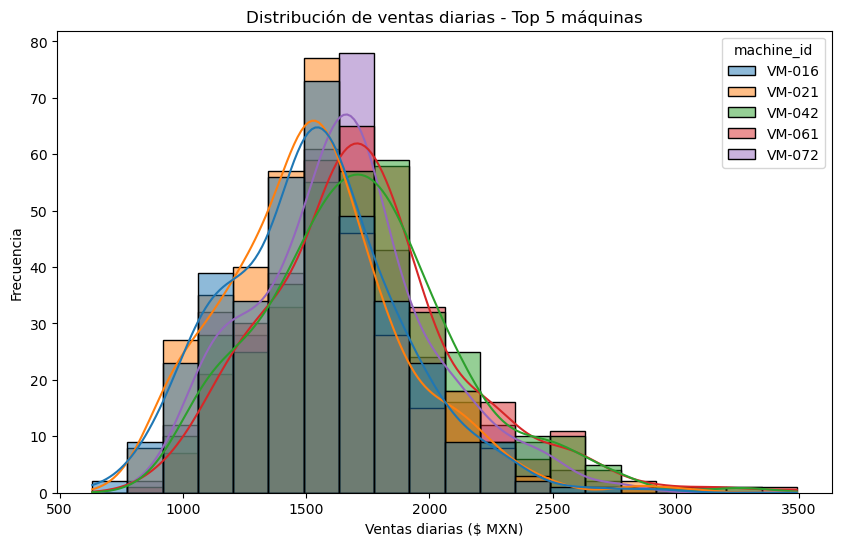

In [23]:
tickets_top = tickets[tickets["machine_id"].isin(top_machines)]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=tickets_top,
    x="net_sales_mxn",
    hue="machine_id",
    bins=20,
    kde=True,
    multiple="layer"
)

plt.title("Distribución de ventas diarias - Top 5 máquinas")
plt.xlabel("Ventas diarias ($ MXN)")
plt.ylabel("Frecuencia")
plt.show()

### 8.6 Variabilidad de ventas por grupo de máquinas

El boxplot permite comparar la mediana, dispersión y valores atípicos de ventas entre grupos de máquinas. Esta visualización es más efectiva que un histograma con demasiadas categorías.

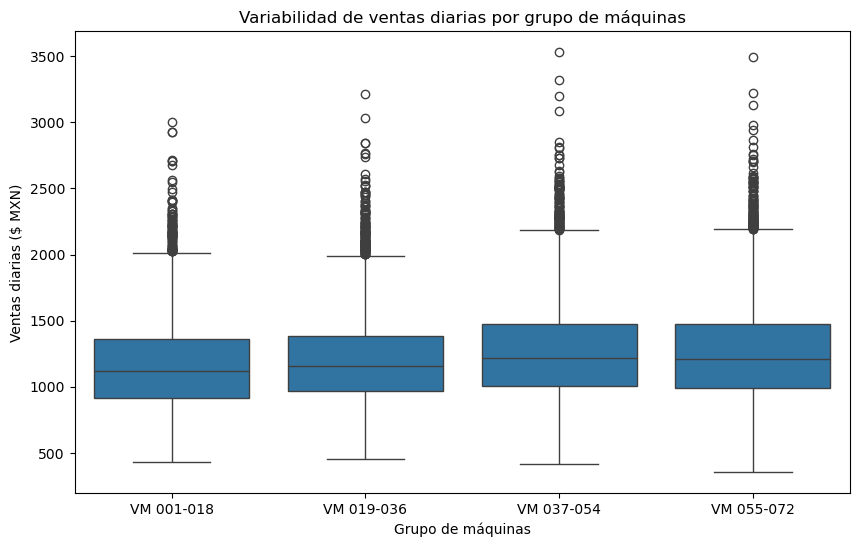

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=tickets,
    x="machine_group",
    y="net_sales_mxn"
)

plt.title("Variabilidad de ventas diarias por grupo de máquinas")
plt.xlabel("Grupo de máquinas")
plt.ylabel("Ventas diarias ($ MXN)")
plt.show()

### 8.7 Identificación de outliers

Se analizan valores atípicos para detectar días con comportamiento fuera de lo normal.

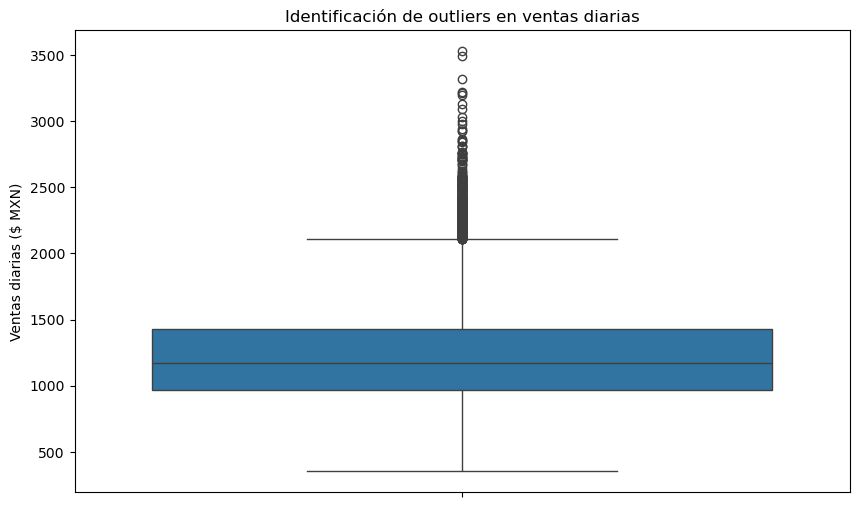

In [25]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=tickets,
    y="net_sales_mxn"
)

plt.title("Identificación de outliers en ventas diarias")
plt.ylabel("Ventas diarias ($ MXN)")
plt.show()

## 9. Insights del análisis visual

La visualización inicial con 72 máquinas individuales no era efectiva, ya que generaba ruido visual y dificultaba la interpretación. Por ello, se optó por un enfoque más ejecutivo:

- Analizar primero la distribución general del sistema.
- Agrupar máquinas en rangos para comparar comportamiento agregado.
- Revisar las máquinas con mayor desempeño de forma individual.
- Usar boxplots para identificar variabilidad y posibles outliers.

Este enfoque permite pasar de una visualización saturada a un análisis más accionable, facilitando decisiones sobre ubicación, desempeño operativo y oportunidades de optimización comercial.

## 10. Conclusión ejecutiva

El análisis de la distribución de ventas diarias en el canal vending permite entender el comportamiento real del negocio desde una perspectiva operativa y comercial.

Principales hallazgos:

- Existe una concentración de ventas en un rango medio, lo que indica estabilidad en la operación.
- Sin embargo, se observa variabilidad entre máquinas, lo que sugiere diferencias en ubicación, demanda o desempeño operativo.
- Las máquinas con mayor desempeño presentan distribuciones distintas, lo que abre oportunidades de replicar condiciones de éxito.
- El uso de agrupaciones y visualizaciones adecuadas permite transformar datos complejos en insights accionables.

## Implicaciones de negocio

- Optimizar máquinas de bajo desempeño mediante pricing o portafolio
- Identificar ubicaciones con alto potencial de consumo
- Replicar patrones de máquinas top performers
- Mejorar la toma de decisiones con base en datos y no intuición

## Próximos pasos

- Integrar variables como ubicación, tipo de cliente o categoría de producto
- Construir un dashboard ejecutivo en Looker Studio
- Analizar tendencias temporales (estacionalidad y crecimiento)

## 11. Análisis por ciudad

Después de entender el comportamiento general del sistema, se analiza la distribución de ventas por ciudad.

El objetivo es identificar si existen diferencias en el desempeño del canal vending según la ubicación geográfica, lo cual puede estar influenciado por factores como demanda, tipo de cliente o tráfico.

In [26]:
tickets = tickets.merge(
    df[["date", "machine_id", "city"]].drop_duplicates(),
    on=["date", "machine_id"],
    how="left"
)

### 11.1 Distribución de ventas por ciudad

Se visualiza la distribución de ventas diarias segmentada por ciudad.

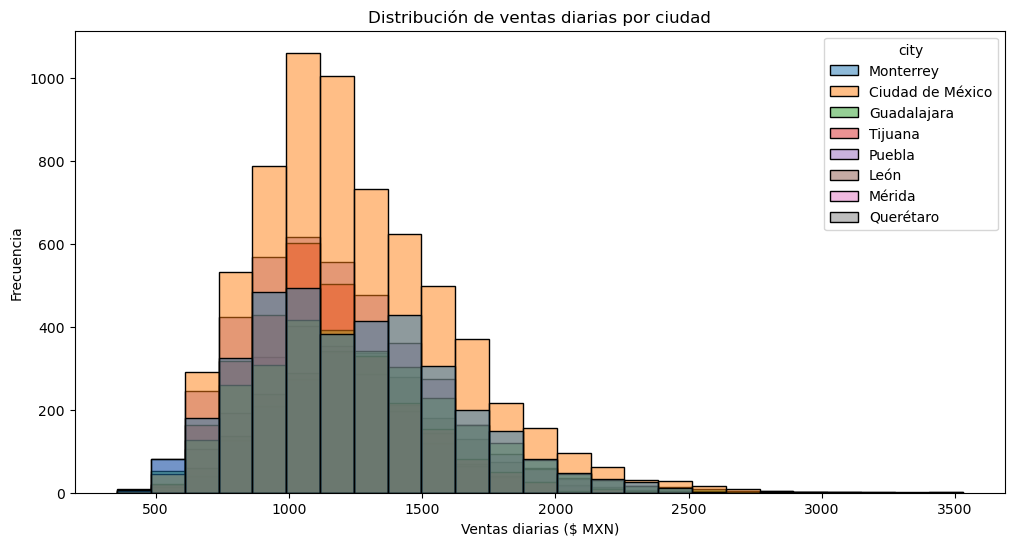

In [27]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=tickets,
    x="net_sales_mxn",
    hue="city",
    bins=25,
    kde=False,
    multiple="layer"
)

plt.title("Distribución de ventas diarias por ciudad")
plt.xlabel("Ventas diarias ($ MXN)")
plt.ylabel("Frecuencia")
plt.show()

### 11.2 Insights por ciudad

Se observan diferencias en la distribución de ventas entre ciudades, lo que sugiere variaciones en el comportamiento de consumo.

Esto puede estar relacionado con:

- densidad poblacional
- tipo de ubicación (hotel, residencial, etc.)
- nivel socioeconómico
- hábitos de compra

## Implicaciones

- priorizar expansión en ciudades con mayor desempeño
- ajustar pricing o portafolio por región
- evaluar desempeño relativo entre mercados

## 12. Análisis por tipo de ubicación

Se analiza el desempeño del canal vending según el tipo de ubicación, con el objetivo de entender qué entornos generan mayor consumo.

In [28]:
tickets = tickets.merge(
    df[["date", "machine_id", "location_type"]].drop_duplicates(),
    on=["date", "machine_id"],
    how="left"
)

### 12.1 Distribución de ventas por tipo de ubicación

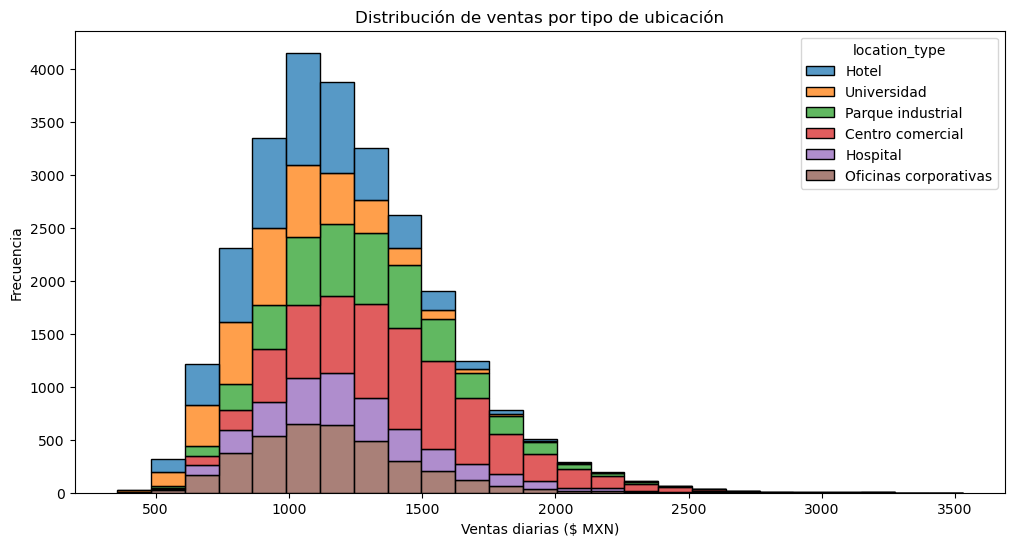

In [31]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=tickets,
    x="net_sales_mxn",
    hue="location_type",
    bins=25,
    kde=False,
    multiple="stack"
)

plt.title("Distribución de ventas por tipo de ubicación")
plt.xlabel("Ventas diarias ($ MXN)")
plt.ylabel("Frecuencia")
plt.show()

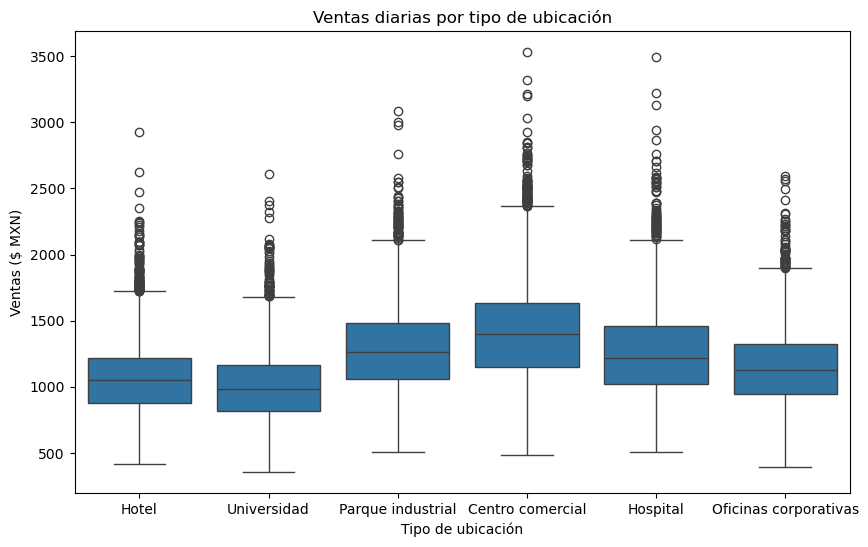

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=tickets,
    x="location_type",
    y="net_sales_mxn"
)

plt.title("Ventas diarias por tipo de ubicación")
plt.xlabel("Tipo de ubicación")
plt.ylabel("Ventas ($ MXN)")
plt.show()

### 12.2 Insights por tipo de ubicación

El análisis muestra diferencias claras en el desempeño de las máquinas según su ubicación.

Algunos tipos de ubicación presentan mayor mediana de ventas y menor variabilidad, lo que indica estabilidad operativa.

Otros presentan mayor dispersión, lo que sugiere oportunidades de optimización o inconsistencia en la demanda.

## Implicaciones

- priorizar instalación en ubicaciones con mayor ticket promedio
- optimizar máquinas en ubicaciones de bajo desempeño
- ajustar portafolio según tipo de cliente
- evaluar ROI por tipo de ubicación

## 13. Análisis combinado: ciudad y tipo de ubicación

Se analiza la interacción entre ciudad y tipo de ubicación para entender combinaciones de alto desempeño.

In [33]:
pivot = tickets.pivot_table(
    values="net_sales_mxn",
    index="city",
    columns="location_type",
    aggfunc="mean"
)

pivot

location_type,Centro comercial,Hospital,Hotel,Oficinas corporativas,Parque industrial,Universidad
city,,,,,,
Ciudad de México,1540.162116,1324.703699,1072.075630,1130.314240,1202.358603,1111.982000
Guadalajara,1523.659763,1153.173863,1130.944027,NaN,1209.178795,813.380137
León,1470.570932,1281.392274,NaN,NaN,1374.941151,1070.765000
Monterrey,1413.880534,NaN,904.525740,1014.880274,1451.249027,987.769726
Mérida,1032.841014,1428.373945,NaN,1268.705452,1163.839342,990.258137
Puebla,1340.757753,NaN,1129.660014,NaN,NaN,1005.928995
Querétaro,1283.702219,NaN,1052.078658,1293.432795,1232.760274,NaN
Tijuana,NaN,1153.706068,1057.948726,1084.024315,1445.612301,1038.767726


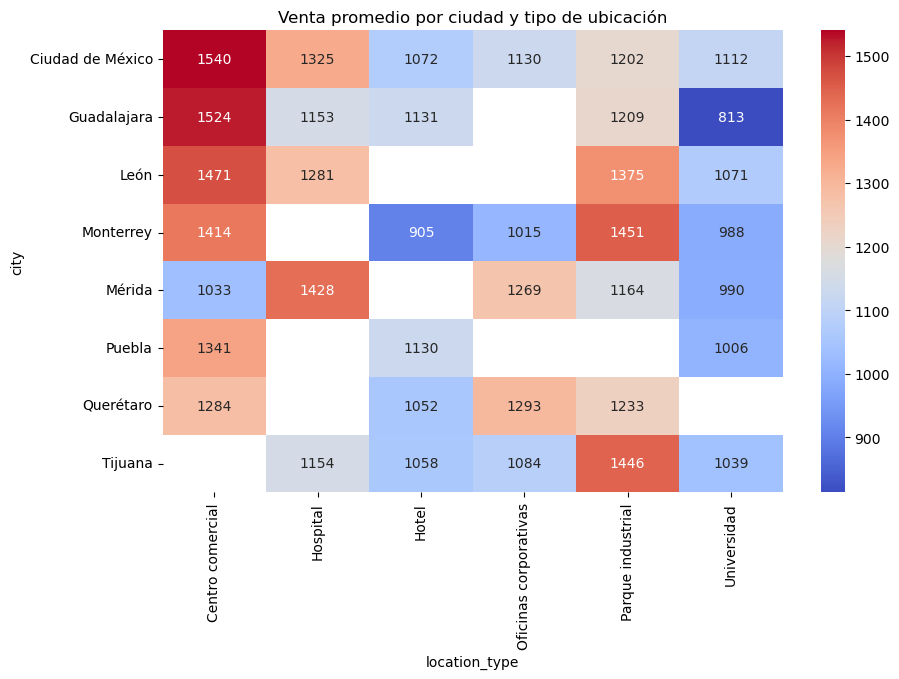

In [34]:
plt.figure(figsize=(10, 6))

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")

plt.title("Venta promedio por ciudad y tipo de ubicación")
plt.show()

## 13.1 Insights estratégicos

El análisis cruzado permite identificar combinaciones específicas de ciudad + tipo de ubicación con mayor potencial de ventas.

Esto habilita decisiones más precisas en:

- expansión del negocio
- selección de ubicaciones
- estrategia comercial

## Implicación clave

No todas las ciudades ni todas las ubicaciones son iguales.

El crecimiento óptimo del negocio depende de identificar las combinaciones correctas.

## Hallazgo clave

El desempeño del canal vending no depende únicamente del volumen de máquinas, sino de la correcta combinación entre ciudad y tipo de ubicación.

Las ubicaciones con mayor tráfico y contexto de consumo inmediato presentan mayor estabilidad y mayor ticket promedio.

## Recomendaciones

- Priorizar instalación en ubicaciones tipo hotel o alto flujo
- Optimizar máquinas de bajo desempeño mediante ajustes de portafolio
- Replicar condiciones de máquinas con alto desempeño
- Usar datos históricos para definir estrategia de expansión

## 14. Hallazgo clave

El desempeño del canal vending no depende únicamente del número de máquinas instaladas, sino de la calidad de la ubicación y del mercado donde opera cada máquina.

La combinación entre ciudad y tipo de ubicación permite identificar patrones de alto desempeño, lo que convierte los datos operativos en una herramienta para decidir dónde expandir, qué máquinas optimizar y qué condiciones replicar.

## 15. Recomendaciones de negocio

A partir del análisis, se proponen las siguientes acciones:

1. Priorizar la expansión en ciudades y tipos de ubicación con mayor venta promedio.
2. Analizar las máquinas con bajo desempeño para ajustar portafolio, precios o ubicación.
3. Replicar las condiciones de las máquinas con mejor comportamiento comercial.
4. Monitorear la variabilidad de ventas para identificar ubicaciones inestables.
5. Construir un dashboard ejecutivo para dar seguimiento mensual al desempeño del canal.

## 16. Conclusión ejecutiva

Este análisis permitió transformar datos operativos del canal vending en insights accionables para la toma de decisiones.

El proyecto muestra que el desempeño comercial del canal puede analizarse mediante distribución de ventas, variabilidad por máquina, segmentación por ciudad y tipo de ubicación.

La principal conclusión es que la estrategia de expansión debe basarse en evidencia: no todas las máquinas ni ubicaciones tienen el mismo potencial, por lo que el crecimiento del modelo vending debe priorizar mercados y ubicaciones con mayor desempeño, estabilidad y rentabilidad esperada.